In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os
import pygad
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Funciones

In [2]:
def train_function(model, optimizer, criterion, scheduler,
                   X_train_s, y_train_s, X_val_s, y_val_s, epochs=300):
    """
    Entrena el modelo con early stopping y scheduler.
    Réplica exacta de src/training/training_functions.py
    """
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(epochs):
        model.train()
        inputs  = torch.FloatTensor(X_train_s)
        targets = torch.FloatTensor(y_train_s)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # Validación
        model.eval()
        with torch.no_grad():
            val_inputs  = torch.FloatTensor(X_val_s)
            val_targets = torch.FloatTensor(y_val_s)
            val_loss = criterion(model(val_inputs), val_targets).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 50 == 0:
            print(f'Época [{epoch+1}/{epochs}]  Train Loss: {loss.item():.4f}  Val Loss: {val_loss:.4f}')

    return best_state, best_val_loss

In [3]:
def eval_function(model, X_scaled, y_raw, scaler_y, split_name="Test", verbose=False):
    """
    Evalúa el modelo. Recibe X ya escalado e y en escala original.
    Métricas alineadas con src/predict/metrics.py
    """
    model.eval()
    with torch.no_grad():
        y_pred_s = model(torch.FloatTensor(X_scaled)).numpy()
        y_pred   = scaler_y.inverse_transform(y_pred_s)
        y_real   = np.array(y_raw).reshape(-1, 1)

    mae          = mean_absolute_error(y_real, y_pred)
    mae_relativo = (mae / np.mean(y_real)) * 100
    r2           = r2_score(y_real, y_pred)
    rmse         = np.sqrt(mean_squared_error(y_real, y_pred))
    rmse_mae_ratio = rmse / mae if mae > 0 else 0

    if verbose:
        print("=" * 55)
        print(f"  MÉTRICAS — {split_name.upper()}")
        print("=" * 55)
        print(f"  R²:            {r2:.4f}")
        print(f"  MAE:           {mae:.2f} L")
        print(f"  MAE relativo:  {mae_relativo:.2f}%")
        print(f"  RMSE:          {rmse:.2f} L")
        print(f"  RMSE/MAE: {rmse_mae_ratio:.2f}")
        print("-" * 55)

        if r2 > 0.95:
            print(f"  ✅ R² > 0.95 — captura >95% de la variabilidad física.")
        elif r2 > 0.90:
            print(f"  ✅ R² > 0.90 — precisión aceptable para despliegue.")
        else:
            print(f"  ❌ R² ≤ 0.90 — revisar arquitectura o datos.")

        if mae_relativo <= 5:
            print(f"  ✅ MAE relativo ≤ 5% — alta precisión porcentual.")
        else:
            print(f"  ⚠️  MAE relativo > 5% — puede limitar la toma de decisiones.")

        ratio = rmse / mae if mae > 0 else 0
        if ratio < 1.2:
            print(f"  ✅ RMSE/MAE = {ratio:.2f} — sin outliers problemáticos.")
        elif ratio < 1.3:
            print(f"  ✅ RMSE/MAE = {ratio:.2f} — dentro del rango aceptable.")
        else:
            print(f"  ⚠️  RMSE/MAE = {ratio:.2f} — posibles errores en casos extremos.")
        print("=" * 55)

    # Scatter real vs predicho
    plt.figure(figsize=(7, 5))
    plt.scatter(y_real, y_pred, alpha=0.4, color='steelblue', s=15)
    lims = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', lw=2)
    plt.title(f'Real vs Predicho — {split_name}  (R²: {r2:.4f})')
    plt.xlabel('Consumo Real de Agua (L)')
    plt.ylabel('Consumo Predicho (L)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return r2, mae, mae_relativo, rmse, rmse_mae_ratio


In [4]:
def predecir_consumo(setpoints, contexto, model_ann, scaler_X, scaler_y):
    input_vector = np.array([[
        contexto['temp_entrada_leche'],
        contexto['temp_ambiente'],
        setpoints[0],   # temp_setpoint_leche
        setpoints[0],   # temp_proceso_leche = setpoint
        setpoints[1],   # temp_agua_servicio
        setpoints[2],   # flujo_leche_lh
        contexto['horas_desde_limpieza'],
        contexto['presion_diferencial_bar']
    ]])
    input_s = scaler_X.transform(input_vector)
    model_ann.eval()
    with torch.no_grad():
        pred_s = model_ann(torch.FloatTensor(input_s)).item()
        return scaler_y.inverse_transform([[pred_s]])[0][0]

In [5]:
# def fitness_func(ga_instance, solution, solution_idx):
#     # solution representa las variables de control: [temp_setpoint, temp_servicio, flujo]
#     t_setpoint, t_servicio, flujo = solution
    
#     # --- RESTRICCIÓN FÍSICA DE SEGURIDAD (PENALIZACIÓN) ---
#     z, t_ref = 7.0, 72.0
#     pu_calculado = 15 * 10**((t_setpoint - t_ref) / z)
    
#     if t_setpoint < 72.0 or pu_calculado < 15:
#         return -10000  # Valor muy bajo para descartar soluciones inseguras

#     # --- PREDICCIÓN CON LA RED NEURONAL ---
#     # Reconstruimos el vector de entrada completo (7 variables) respetando el orden de entrenamiento
#     input_data = np.array([[
#         contexto_hoy['temp_entrada_leche'],
#         contexto_hoy['temp_ambiente'],
#         t_setpoint,
#         t_servicio,
#         flujo,
#         contexto_hoy['horas_desde_limpieza'],
#         contexto_hoy['presion_diferencial_bar']
#     ]])
    
#     input_scaled = scaler_X.transform(input_data)
    
#     model_ann.eval()
#     with torch.no_grad():
#         pred_s = model_ann(torch.FloatTensor(input_scaled)).item()
#         consumo_agua_l = scaler_y.inverse_transform([[pred_s]])[0][0]

#     # Objetivo: Minimizar agua -> Maximizar fitness
#     return 1.0 / (consumo_agua_l + 0.001)

In [6]:
def fitness_func(ga_instance, solution, solution_idx):
    # 1. Preparar entrada y predecir
    input_data = np.array([[
        contexto_hoy['temp_entrada_leche'],
        contexto_hoy['temp_ambiente'],
        solution[0],   # temp_setpoint_leche
        solution[0],   # temp_proceso_leche = setpoint
        solution[1],   # temp_agua_servicio
        solution[2],   # flujo_leche_lh
        contexto_hoy['horas_desde_limpieza'],
        contexto_hoy['presion_diferencial_bar']
    ]])
    input_scaled = scaler_X.transform(input_data)
    
    with torch.no_grad():
        # ¡IMPORTANTE!: Desescalar para tener el consumo real
        consumo_s = model_ann(torch.FloatTensor(input_scaled)).item()
        consumo_real = scaler_y.inverse_transform([[consumo_s]])[0][0]

    # 2. Cálculo de Seguridad (PU)
    t_res = (16 / solution[2]) * 3600 # 16 litros es el volumen del tubo
    pu = t_res * 10**((solution[0] - 72) / 7)
    
    # 3. Retornar Fitness (Maximizar 1/consumo)
    if pu < 15 or solution[0] < 72:
        return 1e-6 # Penalización por inseguridad alimentaria
    
    return 1.0 / (consumo_real + 1e-6)

In [7]:
def optimizacion(contexto, model_ann, scaler_X, scaler_y):
    """Ejecuta el GA con los mismos hiperparámetros que main.py"""
    global contexto_hoy
    contexto_hoy = contexto

    ga_instance = pygad.GA(
        num_generations    = 50,
        num_parents_mating = 5,
        fitness_func       = fitness_func,
        sol_per_pop        = 20,
        num_genes          = 3,
        gene_space         = [
            {'low': 72, 'high': 82},   # temp_setpoint_leche
            {'low': 75, 'high': 92},   # temp_agua_servicio
            {'low': 2500, 'high': 4500} # flujo_leche_lh
        ],
        suppress_warnings  = True,
        random_seed        = 42
    )
    ga_instance.run()
    best_sol, best_fit, _ = ga_instance.best_solution()

    t_res     = (16 / best_sol[2]) * 3600
    pu_logrado = t_res * 10**((best_sol[0] - 72) / 7)

    print(f"  Temp. Leche recomendada:  {best_sol[0]:.2f} °C")
    print(f"  Temp. Agua recomendada:   {best_sol[1]:.2f} °C")
    print(f"  Flujo recomendado:        {best_sol[2]:.0f} L/h")
    print(f"  PU logrado:               {pu_logrado:.2f}")

    ga_instance.plot_fitness(title="Convergencia del Algoritmo Genético")
    return best_sol, best_fit, ga_instance, pu_logrado


In [8]:
def calculo_consumo(setpoints_estandar, setpoints_optimos, contexto_test, model_ann, scaler_X, scaler_y):

    # 5. CÁLCULO DE RESULTADOS
    consumo_estandar = predecir_consumo(setpoints_estandar, contexto_test, model_ann, scaler_X, scaler_y)
    consumo_optimizado = predecir_consumo(setpoints_optimos, contexto_test, model_ann, scaler_X, scaler_y)
    ahorro_l = consumo_estandar - consumo_optimizado
    ahorro_pct = (ahorro_l / consumo_estandar) * 100 if consumo_estandar != 0 else 0

    # ============================================================
    # 📊 VEREDICTO DE AUDITORÍA - PROYECTO DATAGIA
    # ============================================================
    print("\n" + "="*50)
    print("🏆 REPORTE DE OPTIMIZACIÓN HÍDRICA (ANN + GA)")
    print("="*50)
    print(f"🔹 Escenario Contextual: Temp Amb: {contexto_test['temp_ambiente']}°C | Horas Uso: {contexto_test['horas_desde_limpieza']}h")
    print("-"*50)
    print(f"🏭 Consumo ESTÁNDAR:    {consumo_estandar:,.2f} Litros")
    print(f"🚀 Consumo OPTIMIZADO:  {consumo_optimizado:,.2f} Litros")
    print("-"*50)
    print(f"💧 Ahorro Neto:         {ahorro_l:,.2f} Litros")
    print(f"📈 Reducción Lograda:   {ahorro_pct:.2f}%")
    print("-"*50)

    # Verificación de KPI (15% según Guía Modelo 35)
    kpi_objetivo = 15.0
    if ahorro_pct >= kpi_objetivo:
        print(f"✅ ¡KPI SUPERADO! ({ahorro_pct:.2f}% >= {kpi_objetivo}%)")
        print("El modelo es apto para despliegue según los requisitos de la auditoría.")
    else:
        print(f"❌ KPI NO ALCANZADO ({ahorro_pct:.2f}% < {kpi_objetivo}%)")
        print("Se recomienda ajustar la tasa de mutación o el espacio de búsqueda del GA.")
    print("="*50)

    print(f"\n📍 Setpoints Sugeridos por Datagia:")
    print(f"   - Temp. Leche: {setpoints_optimos[0]:.2f}°C (vs 80.0°C)")
    print(f"   - Flujo:       {setpoints_optimos[2]:.0f} L/h (vs 3500 L/h)")


    return consumo_estandar, consumo_optimizado, ahorro_l, ahorro_pct

In [9]:
def validar_seguridad(best_sol):
    # Verificamos si en el proceso de optimización alguna solución rompió la seguridad
    # (En un GA bien configurado, las soluciones finales deben ser todas seguras)
    z, t_ref = 7.0, 72.0
    pu_final = 15 * 10**((best_sol[0] - t_ref) / z)

    print(f"\n🛡️ VALIDACIÓN DE SEGURIDAD ALIMENTARIA (ISO 22000):")
    print(f"   - Valor de Pasteurización (PU) logrado: {pu_final:.2f}")
    print(f"   - Umbral mínimo requerido:              15.00")
    if pu_final >= 15:
        print("   - Estado de seguridad:                  ✅ GARANTIZADO")
    else:
        print("   - Estado de seguridad:                  ❌ CRÍTICO - REVISAR MODELO")

    return pu_final 

In [10]:
def optimizar_escenario(contexto, model_ann, scaler_X, scaler_y):
    # 2. ESCENARIO ESTÁNDAR (Lo que haría un operario sin optimización)
    # Setpoints fijos conservadores para asegurar seguridad siempre
    setpoints_estandar = np.array([80.0, 88.0, 3500.0]) # [Temp_L, Temp_S, Flujo]

    # 3. EJECUCIÓN DEL ALGORITMO GENÉTICO (Búsqueda del Óptimo)
    ga_instance.run()
    setpoints_optimos, fitness_optimo, _ = ga_instance.best_solution()

    consumo_estandar, consumo_optimizado, ahorro_l, ahorro_pct = calculo_consumo(setpoints_estandar, setpoints_optimos, contexto, model_ann, scaler_X, scaler_y)

    pu_final = validar_seguridad(setpoints_optimos)

    return {
        "consumo_estandar": consumo_estandar,
        "consumo_optimizado": consumo_optimizado,
        "ahorro_l": ahorro_l,
        "ahorro_pct": ahorro_pct,
        "pu_final": pu_final
    }

In [11]:
def optimizar_escenarios(escenarios, model_ann, scaler_X, scaler_y):
    resultados = {}
    for i in range(0,4):
        
        temp_entrada_leche = escenarios['temp_entrada_leche'][i]
        temp_ambiente = escenarios['temp_ambiente'][i]
        horas_desde_limpieza = escenarios['horas_desde_limpieza'][i]
        presion_diferencial_bar = escenarios['presion_diferencial_bar'][i]

        contexto = {"temp_entrada_leche": temp_entrada_leche,
                    "temp_ambiente": temp_ambiente,
                    "horas_desde_limpieza": horas_desde_limpieza,
                    "presion_diferencial_bar": presion_diferencial_bar
        }

        print("\n" + "="*50)
        print(f"OPTIMIZACIÓN DEL ESCENARIO {i}")
        print("="*50)

        dict_resultados = optimizar_escenario(contexto, model_ann, scaler_X, scaler_y)
        resultados[i] = dict_resultados
        
    return resultados

# Model 

In [12]:
# Definición de la Arquitectura MEJORADA
class Model(nn.Module):
    def __init__(self, input_size):
        super(Model, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.network(x)

# Pipeline

In [13]:
data_path = '../../data/processed/milk_dataset.csv'
model_path = '../../models/artifacts/'
metrics_path = '../../models/metrics/'
RANDOM_SEED = 42
os.makedirs(model_path, exist_ok=True)
os.makedirs(metrics_path, exist_ok=True)

# 1. Cargar y analizar datos
df_final = pd.read_csv(data_path)


In [14]:
# ── Features y target ───────────────────────────────────────────────────────
X_cols = [
    'temp_entrada_leche', 'temp_ambiente',
    'temp_setpoint_leche', 'temp_proceso_leche',
    'temp_agua_servicio', 'flujo_leche_lh',
    'horas_desde_limpieza', 'presion_diferencial_bar'
]
y_col = 'consumo_agua_l'

X = df_final[X_cols].values
y = df_final[y_col].values.reshape(-1, 1)

# ── Partición 70 / 15 / 15 ──────────────────────────────────────────────────
# Idéntica a split_and_save_splits() en src/training/training_functions.py
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED
)

print(f"Train : {len(X_train):>6,} muestras  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):>6,} muestras  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):>6,} muestras  ({len(X_test)/len(X)*100:.1f}%)")


Train :  3,500 muestras  (70.0%)
Val   :    750 muestras  (15.0%)
Test  :    750 muestras  (15.0%)


In [15]:
# ── Escalado ────────────────────────────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
y_train_s = scaler_y.fit_transform(y_train)
X_val_s   = scaler_X.transform(X_val)
y_val_s   = scaler_y.transform(y_val)
X_test_s  = scaler_X.transform(X_test)

# ── Instanciar modelo ────────────────────────────────────────────────────────
model_ann = Model(len(X_cols))
optimizer = optim.Adam(model_ann.parameters(), lr=0.005)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5
)

# ── Entrenar ─────────────────────────────────────────────────────────────────
best_state, best_val_loss = train_function(
    model_ann, optimizer, criterion, scheduler,
    X_train_s, y_train_s, X_val_s, y_val_s, epochs=300
)
model_ann.load_state_dict(best_state)
print(f"\nMejor val loss: {best_val_loss:.6f}")

Época [50/300]  Train Loss: 0.0322  Val Loss: 0.0082
Época [100/300]  Train Loss: 0.0234  Val Loss: 0.0076
Época [150/300]  Train Loss: 0.0215  Val Loss: 0.0067
Época [200/300]  Train Loss: 0.0213  Val Loss: 0.0064
Época [250/300]  Train Loss: 0.0217  Val Loss: 0.0064
Época [300/300]  Train Loss: 0.0226  Val Loss: 0.0064

Mejor val loss: 0.005647


# Resultados

## Resultados ANN

>>> TRAIN
  MÉTRICAS — TRAIN
  R²:            0.9945
  MAE:           301.63 L
  MAE relativo:  1.26%
  RMSE:          369.92 L
  RMSE/MAE: 1.23
-------------------------------------------------------
  ✅ R² > 0.95 — captura >95% de la variabilidad física.
  ✅ MAE relativo ≤ 5% — alta precisión porcentual.
  ✅ RMSE/MAE = 1.23 — dentro del rango aceptable.


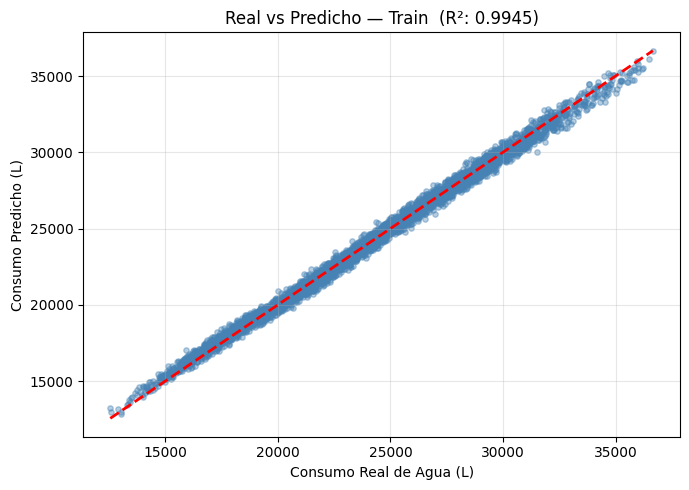


>>> VALIDACIÓN
  MÉTRICAS — VALIDACIÓN
  R²:            0.9943
  MAE:           307.74 L
  MAE relativo:  1.27%
  RMSE:          376.18 L
  RMSE/MAE: 1.22
-------------------------------------------------------
  ✅ R² > 0.95 — captura >95% de la variabilidad física.
  ✅ MAE relativo ≤ 5% — alta precisión porcentual.
  ✅ RMSE/MAE = 1.22 — dentro del rango aceptable.


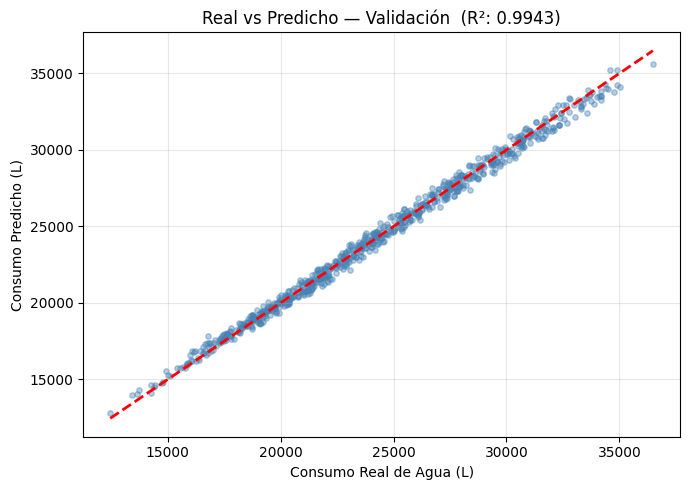


>>> TEST
  MÉTRICAS — TEST
  R²:            0.9947
  MAE:           304.62 L
  MAE relativo:  1.25%
  RMSE:          375.11 L
  RMSE/MAE: 1.23
-------------------------------------------------------
  ✅ R² > 0.95 — captura >95% de la variabilidad física.
  ✅ MAE relativo ≤ 5% — alta precisión porcentual.
  ✅ RMSE/MAE = 1.23 — dentro del rango aceptable.


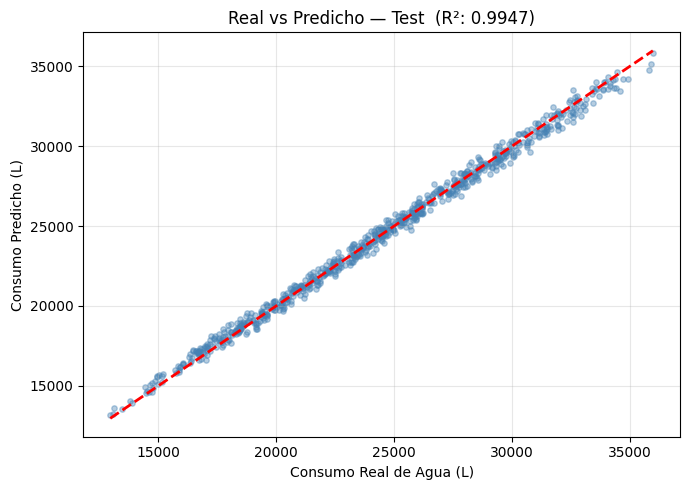

In [16]:
# ── Evaluación en los tres splits ───────────────────────────────────────────
print(">>> TRAIN")
r2_train, mae_train, mae_rel_train, rmse_train, rmse_rel_train = eval_function(
    model_ann, X_train_s, y_train, scaler_y, split_name="Train", verbose=True
)

print("\n>>> VALIDACIÓN")
r2_val, mae_val, mae_rel_val, rmse_val, rmse_rel_val = eval_function(
    model_ann, X_val_s, y_val, scaler_y, split_name="Validación", verbose=True
)

print("\n>>> TEST")
r2_test, mae_test, mae_rel_test, rmse_test, rmse_rel_test = eval_function(
    model_ann, X_test_s, y_test, scaler_y, split_name="Test", verbose=True
)


## Tabla de referencia de métricas

| Métrica        | Objetivo      | Significado para la auditoría                            |
|----------------|---------------|----------------------------------------------------------|
| R²             | > 0.90        | El modelo predice el consumo de agua con alta fidelidad. |
| MAE relativo   | < 5 %         | Error medio despreciable frente al volumen total.        |
| RMSE / MAE     | < 1.30        | Sin outliers problemáticos en la predicción.             |
| Ahorro %       | ≥ 15 %        | KPI de la Guía Modelo 35 (Datagia).                      |
| PU Score       | ≥ 13          | El ahorro no compromete la seguridad alimentaria.        |


## Optimización — Escenario único

  Temp. Leche recomendada:  72.12 °C
  Temp. Agua recomendada:   75.08 °C
  Flujo recomendado:        2510 L/h
  PU logrado:               23.88


c:\Users\riera\Documents\Proyectos\DATAGIA\modelo_35\venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


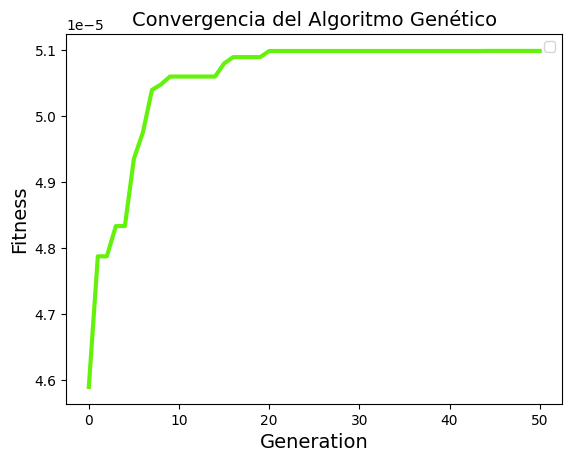

In [17]:
# ── Contexto del operario (día de verano, máquina sucia) ────────────────────
contexto_hoy = {
    'temp_entrada_leche'     : 10.0,
    'temp_ambiente'          : 30.0,
    'horas_desde_limpieza'   : 12.0,
    'presion_diferencial_bar': 1.8
}

best_sol, best_fit, ga_instance, pu_logrado = optimizacion(
    contexto_hoy, model_ann, scaler_X, scaler_y
)

## Resultado optimización

In [18]:
# 1. DEFINICIÓN DEL ESCENARIO DE PRUEBA (Contexto captado por IIoT)
# Escenario: Día de verano, leche entra templada, máquina lleva 15h sin limpiarse.
contexto_test = {
    'temp_entrada_leche': 14.0,
    'temp_ambiente': 32.0,
    'horas_desde_limpieza': 15.0,
    'presion_diferencial_bar': 2.2 # Presión alta por fouling
}

resultados_optimizacion = optimizar_escenario(contexto_test, model_ann, scaler_X, scaler_y)


🏆 REPORTE DE OPTIMIZACIÓN HÍDRICA (ANN + GA)
🔹 Escenario Contextual: Temp Amb: 32.0°C | Horas Uso: 15.0h
--------------------------------------------------
🏭 Consumo ESTÁNDAR:    27,889.91 Litros
🚀 Consumo OPTIMIZADO:  21,072.43 Litros
--------------------------------------------------
💧 Ahorro Neto:         6,817.48 Litros
📈 Reducción Lograda:   24.44%
--------------------------------------------------
✅ ¡KPI SUPERADO! (24.44% >= 15.0%)
El modelo es apto para despliegue según los requisitos de la auditoría.

📍 Setpoints Sugeridos por Datagia:
   - Temp. Leche: 72.01°C (vs 80.0°C)
   - Flujo:       2510 L/h (vs 3500 L/h)

🛡️ VALIDACIÓN DE SEGURIDAD ALIMENTARIA (ISO 22000):
   - Valor de Pasteurización (PU) logrado: 15.07
   - Umbral mínimo requerido:              15.00
   - Estado de seguridad:                  ✅ GARANTIZADO


In [19]:
# ---------------------------------------------------------
# 1. DEFINICIÓN DE ESCENARIOS (Simulación de variabilidad)
# ---------------------------------------------------------
escenarios = {
    'temp_entrada_leche': [4.0, 10.0, 15.0, 5.0],
    'temp_ambiente': [15.0, 25.0, 35.0, 20.0],
    'horas_desde_limpieza': [2.0, 8.0, 15.0, 19.0],
    'presion_diferencial_bar': [0.5, 0.9, 1.8, 2.1]
}


resultados = optimizar_escenarios(escenarios, model_ann, scaler_X, scaler_y)


OPTIMIZACIÓN DEL ESCENARIO 0

🏆 REPORTE DE OPTIMIZACIÓN HÍDRICA (ANN + GA)
🔹 Escenario Contextual: Temp Amb: 15.0°C | Horas Uso: 2.0h
--------------------------------------------------
🏭 Consumo ESTÁNDAR:    19,795.63 Litros
🚀 Consumo OPTIMIZADO:  12,984.01 Litros
--------------------------------------------------
💧 Ahorro Neto:         6,811.62 Litros
📈 Reducción Lograda:   34.41%
--------------------------------------------------
✅ ¡KPI SUPERADO! (34.41% >= 15.0%)
El modelo es apto para despliegue según los requisitos de la auditoría.

📍 Setpoints Sugeridos por Datagia:
   - Temp. Leche: 72.01°C (vs 80.0°C)
   - Flujo:       2502 L/h (vs 3500 L/h)

🛡️ VALIDACIÓN DE SEGURIDAD ALIMENTARIA (ISO 22000):
   - Valor de Pasteurización (PU) logrado: 15.07
   - Umbral mínimo requerido:              15.00
   - Estado de seguridad:                  ✅ GARANTIZADO

OPTIMIZACIÓN DEL ESCENARIO 1

🏆 REPORTE DE OPTIMIZACIÓN HÍDRICA (ANN + GA)
🔹 Escenario Contextual: Temp Amb: 25.0°C | Horas Uso: 8.0

In [20]:
# plt.figure(figsize=(10,6))
# plt.bar(df_resultados_opt['escenario'], df_resultados_opt['consumo_estimado'], color='skyblue')
# plt.xlabel('ID Escenario (Variaciones IIoT)')
# plt.ylabel('Consumo de Agua Optimizado (L)')
# plt.title('Rendimiento del Modelo Genético en Diferentes Condiciones de Planta')
# plt.show()